### Model

In [14]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import joblib
import os

In [15]:
# Load dataset
df = pd.read_csv('../data/processed/final_features.csv')

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Sort data (VERY IMPORTANT for time series)
df = df.sort_values('date')

df.head()

,date,cpi,wpi,month,year,quarter,lag_1,lag_2,lag_3,lag_6,...,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,cpi_pct_change,cpi_diff,wpi_pct_change,wpi_lag1,trend_index,cpi_wpi_diff
0,2013-04-01,106.1,108.6,4,2013,2,105.5,105.3,104.6,103.6,...,105.633333,0.416333,105.066667,0.683130,0.568720,0.6,0.000000,108.6,12,-2.5
1,2013-05-01,106.9,108.6,5,2013,2,106.1,105.5,105.3,104.3,...,106.166667,0.702377,105.500000,0.892188,0.754006,0.8,0.000000,108.6,13,-1.7
2,2013-06-01,109.3,110.1,6,2013,2,106.9,106.1,105.5,104.6,...,107.433333,1.665333,106.283333,1.669032,2.245089,2.4,1.381215,108.6,14,-0.8
3,2013-07-01,111.0,111.2,7,2013,3,109.3,106.9,106.1,104.6,...,109.066667,2.059935,107.350000,2.302824,1.555352,1.7,0.999092,110.1,15,-0.2
4,2013-08-01,112.4,112.9,8,2013,3,111.0,109.3,106.9,105.3,...,110.900000,1.552417,108.533333,2.807609,1.261261,1.4,1.528777,111.2,16,-0.5


#### Train-Test Split

In [16]:
# Time-based split
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

#### Define Features & Target

In [17]:
# Define features and target
X_train = train.drop(['date', 'cpi'], axis=1)
y_train = train['cpi']

X_test = test.drop(['date', 'cpi'], axis=1)
y_test = test['cpi']

print("Features used:", X_train.columns.tolist())

Features used: ['wpi', 'month', 'year', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'cpi_pct_change', 'cpi_diff', 'wpi_pct_change', 'wpi_lag1', 'trend_index', 'cpi_wpi_diff']


#### Train Models

In [18]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# XGBoost (FINAL MODEL)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

#### Evaluation Function

In [19]:
# Evaluation function
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Safe MAPE (avoid divide by zero)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    return mae, rmse, mape

#### Evaluate Models

In [20]:
# Evaluate all models
lr_metrics = evaluate(y_test, lr_pred)
rf_metrics = evaluate(y_test, rf_pred)
xgb_metrics = evaluate(y_test, xgb_pred)

print("Linear Regression:", lr_metrics)
print("Random Forest:", rf_metrics)
print("XGBoost:", xgb_metrics)

Linear Regression: (4.1257320140909044e-14, np.float64(4.6505936511979476e-14), np.float64(2.152984798016964e-14))
Random Forest: (14.12316129032248, np.float64(15.066066485809632), np.float64(7.321369291289087))
XGBoost: (12.34132582141507, np.float64(13.236009192057663), np.float64(6.395261137624743))


#### Compare Results

In [21]:
# Create results table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_metrics[0], rf_metrics[0], xgb_metrics[0]],
    'RMSE': [lr_metrics[1], rf_metrics[1], xgb_metrics[1]],
    'MAPE': [lr_metrics[2], rf_metrics[2], xgb_metrics[2]]
})

# Sort by best model
results = results.sort_values('RMSE').reset_index(drop=True)

print(results)

               Model           MAE          RMSE          MAPE
0  Linear Regression  4.125732e-14  4.650594e-14  2.152985e-14
1            XGBoost  1.234133e+01  1.323601e+01  6.395261e+00
2      Random Forest  1.412316e+01  1.506607e+01  7.321369e+00


#### BEST MODEL SELECTION

In [22]:
# Best model
best_model = results.iloc[0]

print("✅ Best Model:", best_model['Model'])

✅ Best Model: Linear Regression


#### Plot Predictions

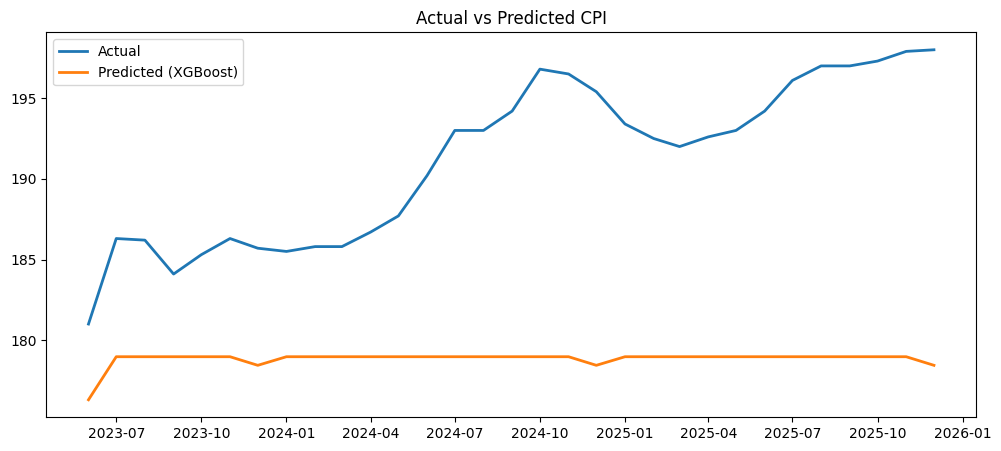

In [27]:
# Plot actual vs predicted
plt.figure(figsize=(12,5))

plt.plot(test['date'], y_test.values, label='Actual', linewidth=2)
plt.plot(test['date'], xgb_pred, label='Predicted (XGBoost)', linewidth=2)

plt.legend()
plt.title("Actual vs Predicted CPI")

plt.savefig('../reports/Actual vs Predicted CPI.png')

plt.show()

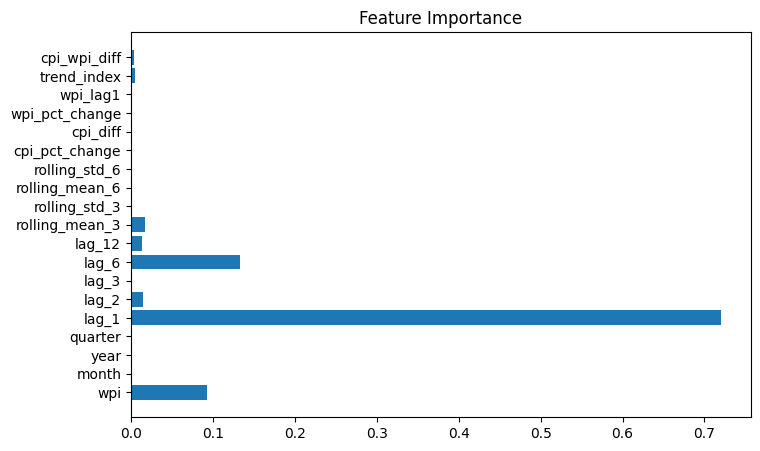

In [11]:
# Feature importance (for XGBoost)
plt.figure(figsize=(8,5))

plt.barh(X_train.columns, xgb.feature_importances_)
plt.title("Feature Importance")

plt.show()

In [25]:
# Save model
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb, '../models/best_model.pkl')

print("✅ Model saved successfully")

✅ Model saved successfully


In [26]:
# Save results
os.makedirs('../reports', exist_ok=True)

results.to_csv('../reports/model_results.csv', index=False)

print("✅ Results saved successfully")

✅ Results saved successfully


In [32]:
# ==============================
# FUTURE PREDICTION (NEXT 6 MONTHS)
# ==============================

future_steps = 6

last_row = df.iloc[-1:].copy()
future_preds = []

for i in range(future_steps):
    
    # Prepare input (same features as training)
    X_last = last_row.drop(['date', 'cpi'], axis=1)
    
    # Predict
    next_pred = xgb.predict(X_last)[0]
    future_preds.append(next_pred)
    
    # Update for next step
    last_row['cpi'] = next_pred
    last_row['lag_1'] = next_pred

# Create future dates
future_dates = pd.date_range(start=df['date'].iloc[-1], periods=future_steps+1, freq='ME')[1:]

# Create dataframe
future_df = pd.DataFrame({
    'date': future_dates,
    'predicted_cpi': future_preds
})

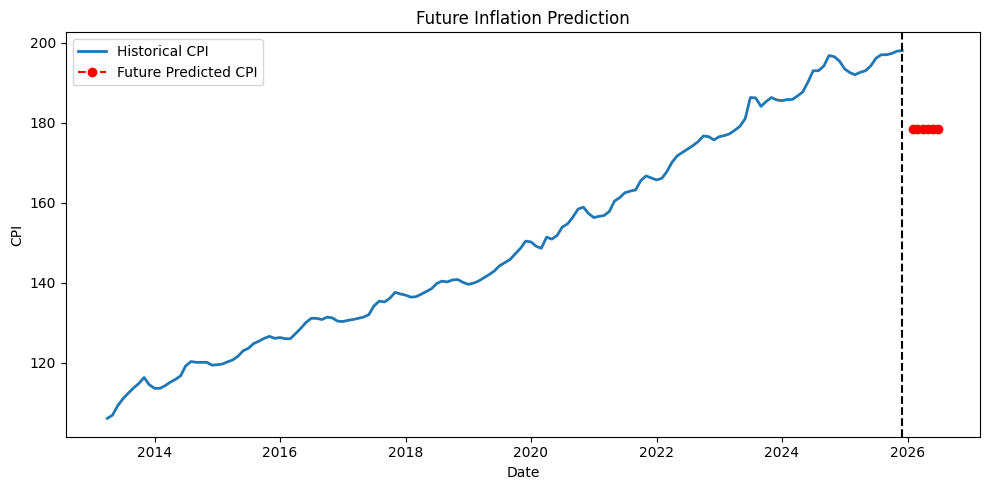

In [34]:
plt.figure(figsize=(10,5))

# Historical CPI
plt.plot(df['date'], df['cpi'], label='Historical CPI', linewidth=2)

# Future CPI
plt.plot(future_df['date'], future_df['predicted_cpi'],
         linestyle='dashed', marker='o',
         label='Future Predicted CPI', color='red')

# Separation line
plt.axvline(x=df['date'].iloc[-1], linestyle='--', color='black')

plt.legend()
plt.title("Future Inflation Prediction")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.tight_layout()
plt.savefig('../reports/future_prediction.png')
plt.show()